# Laptop Price Prediction

### Algorithm
- Multiple Linear Regression

### Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MSE (Mean Squared Error)
- R² Score

#### Import Libraries

In [1]:
from shlex import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylab
import seaborn as sns
import sklearn.preprocessing as prep



#### Load Dataset

In [2]:
df=pd.read_csv('laptop_price.csv')

#### Data Exploration

In [3]:
df.head(10)

,laptop_ID,Company,Product,TypeName,Inches,Cpu,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,IPS Panel Retina Display 2560x1600,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,1440x900,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,Full HD 1920x1080,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,IPS Panel Retina Display 2880x1800,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,IPS Panel Retina Display 2560x1600,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
5,6,Acer,Aspire 3,Notebook,15.6,AMD A9-Series 9420 3GHz,1366x768,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00
6,7,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.2GHz,IPS Panel Retina Display 2880x1800,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97
7,8,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,1440x900,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,1158.70
8,9,Asus,ZenBook UX430UN,Ultrabook,14.0,Intel Core i7 8550U 1.8GHz,Full HD 1920x1080,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,1495.00
9,10,Acer,Swift 3,Ultrabook,14.0,Intel Core i5 8250U 1.6GHz,IPS Panel Full HD 1920x1080,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,770.00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   Cpu               1303 non-null   str    
 6   ScreenResolution  1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [5]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [6]:
df.nunique()

laptop_ID           1303
Company               19
Product              618
TypeName               6
Inches                18
Cpu                  118
ScreenResolution      40
Ram                    9
Memory                39
Gpu                  110
OpSys                  9
Weight               179
Price_euros          791
dtype: int64

#### Data Cleaning

In [7]:
clean_df=df.drop(['laptop_ID','Product'],axis=1)
clean_df['Weight']=clean_df['Weight'].str.replace('kg','').astype('float')
clean_df['Ram']=clean_df['Ram'].str.replace('GB','').astype('float')
clean_df['OpSys']=clean_df['OpSys'].replace({
    "Windows 10":'Windows',
    "Windows 7":'Windows',
    "Windows 10 S":'Windows',
    "Mac OS X":'macOS'
})
clean_df.head()

,Company,TypeName,Inches,Cpu,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,IPS Panel Retina Display 2560x1600,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,1440x900,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,Full HD 1920x1080,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,IPS Panel Retina Display 2880x1800,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,IPS Panel Retina Display 2560x1600,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


In [8]:
clean_df.duplicated().sum()

np.int64(30)

In [9]:
clean_df=clean_df.drop_duplicates()

In [10]:
clean_df.isnull().sum()

Company             0
TypeName            0
Inches              0
Cpu                 0
ScreenResolution    0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

#### EDA (Exploratory Data Analysis)

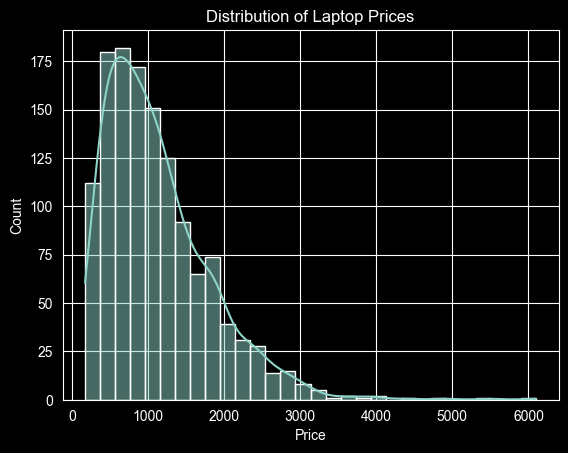

In [11]:
sns.histplot(df['Price_euros'], bins=30, kde=True)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

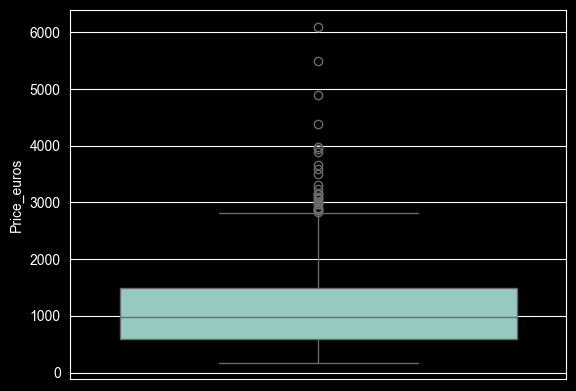

In [12]:
sns.boxplot(df['Price_euros'])
plt.show()

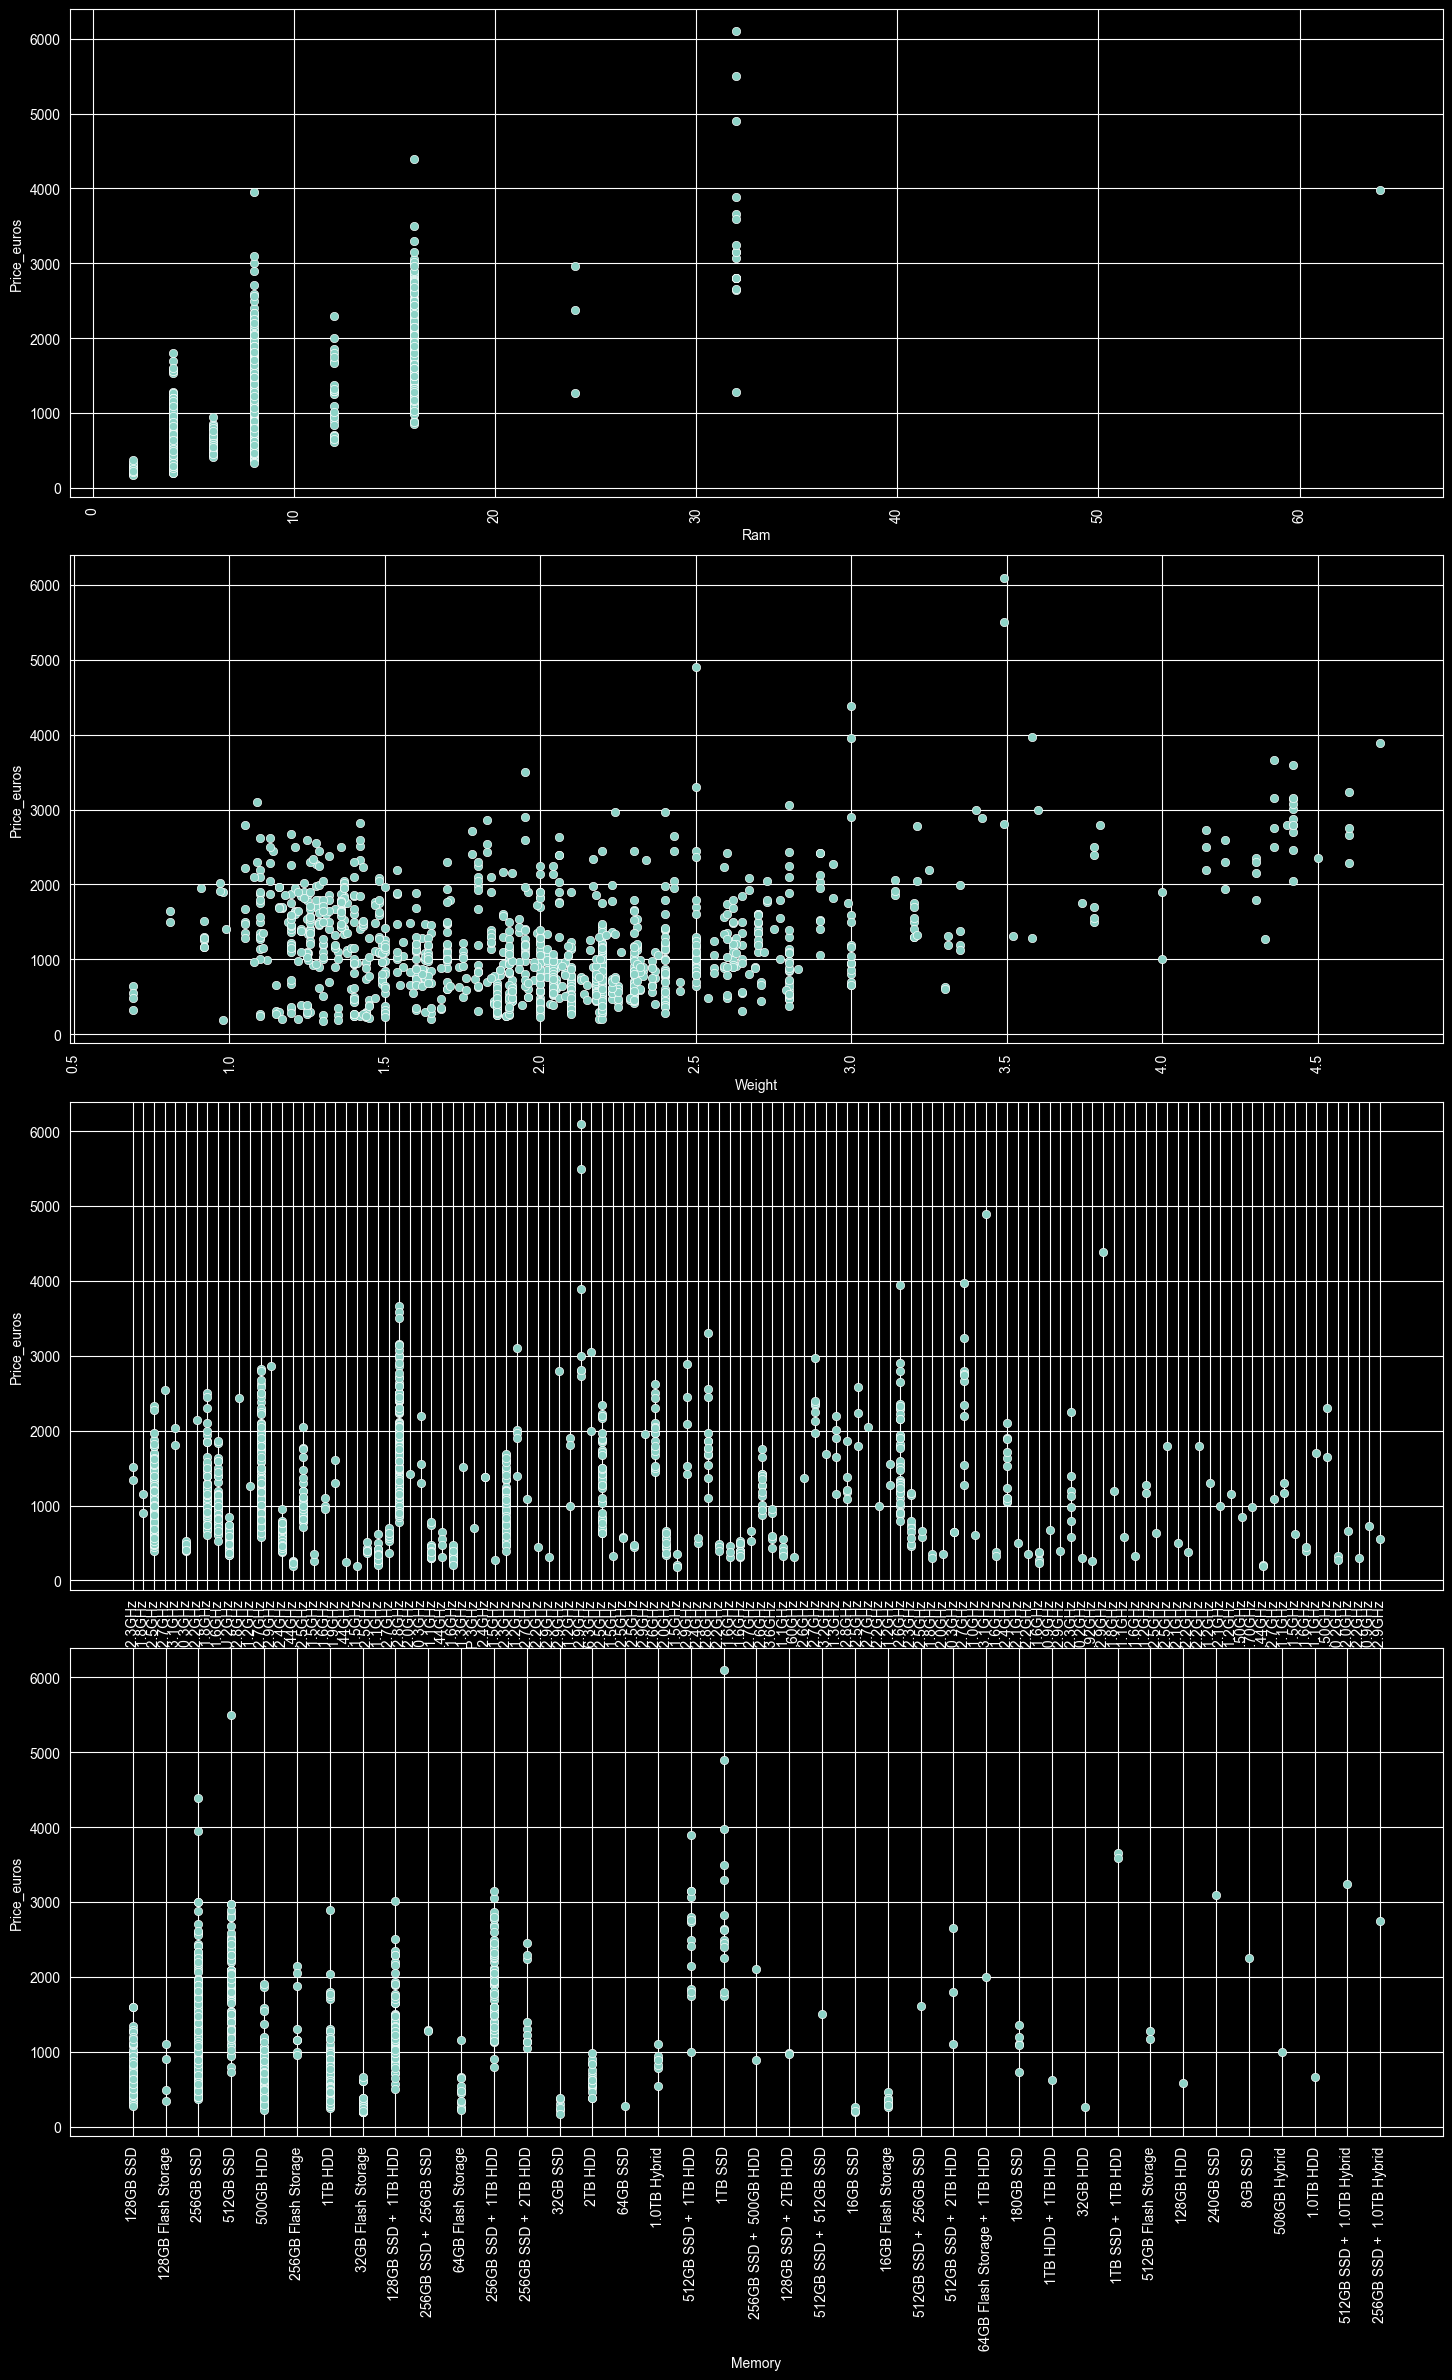

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(15, 22))

sns.scatterplot(data=clean_df, x="Ram", y="Price_euros", ax=axes[0])

sns.scatterplot(data=clean_df, x="Weight", y="Price_euros", ax=axes[1])

sns.scatterplot(data=clean_df, x="Cpu", y="Price_euros", ax=axes[2])

sns.scatterplot(data=clean_df, x="Memory", y="Price_euros", ax=axes[3])
plt.tight_layout()
for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation=90)
plt.show()

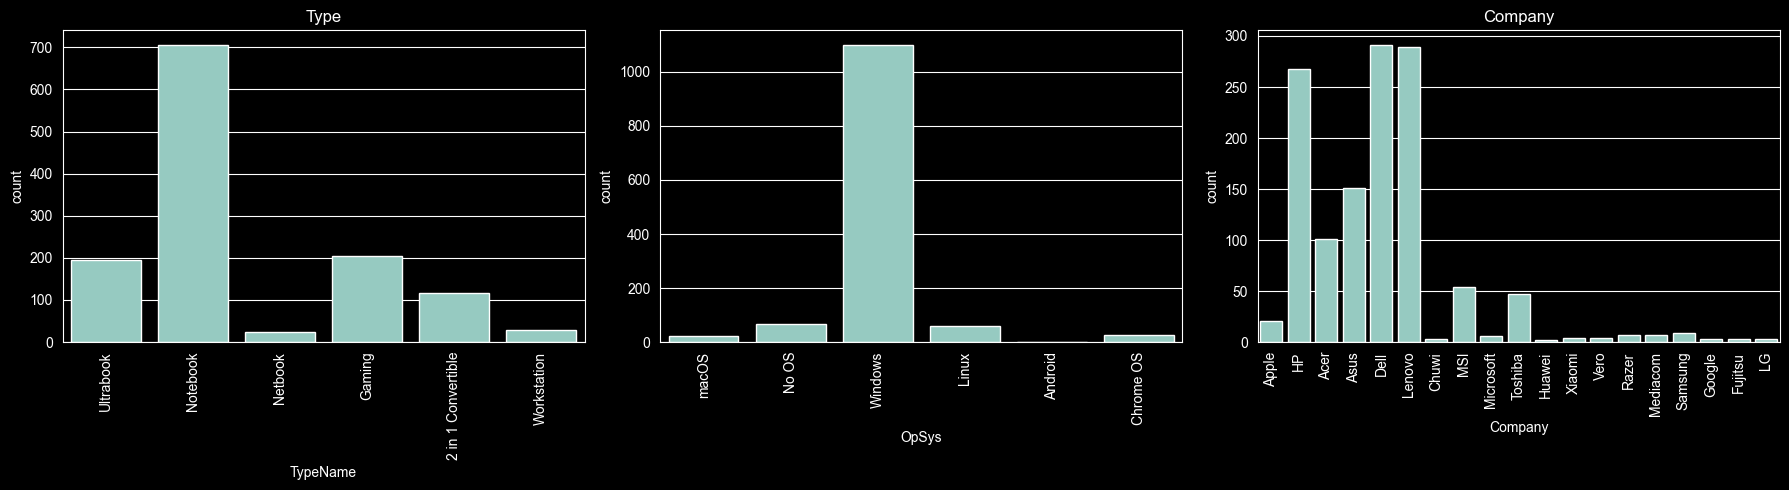

In [14]:
fig1,axe=plt.subplots(1,3,figsize=(18,5))

sns.countplot(data=clean_df,x="OpSys",ax=axe[1])

sns.countplot(data=clean_df, x="Company", ax=axe[2])
axe[2].set_title("Company")

sns.countplot(data=clean_df, x="TypeName", ax=axe[0])
axe[0].set_title("Type")

for ax in axe.flat:
    ax.tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

#### Feature Engineering

In [15]:
clean_df["resolution"] = clean_df["ScreenResolution"].str.extract(r"(\d+x\d+)")
clean_df['x_res']=clean_df["resolution"].str.split("x").str[0].astype(int)
clean_df['y_res']=clean_df["resolution"].str.split("x").str[1].astype(int)
clean_df["IPS"]=clean_df["ScreenResolution"].str.contains('IPS',case=False).astype(bool)
clean_df["Touchscreen"]=clean_df["ScreenResolution"].str.contains('Touchscreen',case=False).astype(bool)
clean_df["PPI"]=(np.sqrt(clean_df["x_res"]**2+
                        clean_df["y_res"]**2)/clean_df["Inches"])
clean_df=clean_df.drop(columns=["ScreenResolution",'resolution'])
clean_df.head(10)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,x_res,y_res,IPS,Touchscreen,PPI
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600,True,False,226.983005
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900,False,False,127.677940
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080,False,False,141.211998
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800,True,False,220.534624
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600,True,False,226.983005
5,Acer,Notebook,15.6,AMD A9-Series 9420 3GHz,4.0,500GB HDD,AMD Radeon R5,Windows,2.10,400.00,1366,768,False,False,100.454670
6,Apple,Ultrabook,15.4,Intel Core i7 2.2GHz,16.0,256GB Flash Storage,Intel Iris Pro Graphics,macOS,2.04,2139.97,2880,1800,True,False,220.534624
7,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8.0,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,1158.70,1440,900,False,False,127.677940
8,Asus,Ultrabook,14.0,Intel Core i7 8550U 1.8GHz,16.0,512GB SSD,Nvidia GeForce MX150,Windows,1.30,1495.00,1920,1080,False,False,157.350512
9,Acer,Ultrabook,14.0,Intel Core i5 8250U 1.6GHz,8.0,256GB SSD,Intel UHD Graphics 620,Windows,1.60,770.00,1920,1080,True,False,157.350512


In [16]:
for i in sorted(clean_df['Cpu'].unique()):
    print(i)

AMD A10-Series 9600P 2.4GHz
AMD A10-Series 9620P 2.5GHz
AMD A10-Series A10-9620P 2.5GHz
AMD A12-Series 9700P 2.5GHz
AMD A12-Series 9720P 2.7GHz
AMD A12-Series 9720P 3.6GHz
AMD A4-Series 7210 2.2GHz
AMD A6-Series 7310 2GHz
AMD A6-Series 9220 2.5GHz
AMD A6-Series 9220 2.9GHz
AMD A6-Series A6-9220 2.5GHz
AMD A8-Series 7410 2.2GHz
AMD A9-Series 9410 2.9GHz
AMD A9-Series 9420 2.9GHz
AMD A9-Series 9420 3GHz
AMD A9-Series A9-9420 3GHz
AMD E-Series 6110 1.5GHz
AMD E-Series 7110 1.8GHz
AMD E-Series 9000 2.2GHz
AMD E-Series 9000e 1.5GHz
AMD E-Series E2-6110 1.5GHz
AMD E-Series E2-9000 2.2GHz
AMD E-Series E2-9000e 1.5GHz
AMD FX 8800P 2.1GHz
AMD FX 9830P 3GHz
AMD Ryzen 1600 3.2GHz
AMD Ryzen 1700 3GHz
Intel Atom X5-Z8350 1.44GHz
Intel Atom Z8350 1.92GHz
Intel Atom x5-Z8300 1.44GHz
Intel Atom x5-Z8350 1.44GHz
Intel Atom x5-Z8550 1.44GHz
Intel Celeron Dual Core 3205U 1.5GHz
Intel Celeron Dual Core 3855U 1.6GHz
Intel Celeron Dual Core N3050 1.6GHz
Intel Celeron Dual Core N3060 1.60GHz
Intel Celeron Du

In [17]:
def get_series(cpu):
    cpu=str(cpu)
    keys=['A10-Series','A12-Series','A4-Series','A6-Series','A8-Series','A9-Series','E-Series','FX','Ryzen','Atom','Celeron Dual Core','Core M','Core i3','Core i5','Core i7','Pentium Dual Core','Xeon','Cortex']
    for i in keys:
        if i.lower() in cpu.lower():
            return i
    return "other"


clean_df["CPU_brand"]=clean_df["Cpu"].str.split().str[0]
clean_df["CPU_model"]=clean_df["Cpu"].apply(get_series)
clean_df["CPU_GHz"]=clean_df["Cpu"].str.split().str[-1].str.replace("GHz","").astype(float)

clean_df.drop(columns=["Cpu"], inplace=True)
clean_df.head(10)

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price_euros,x_res,y_res,IPS,Touchscreen,PPI,CPU_brand,CPU_model,CPU_GHz
0,Apple,Ultrabook,13.3,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600,True,False,226.983005,Intel,Core i5,2.3
1,Apple,Ultrabook,13.3,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900,False,False,127.677940,Intel,Core i5,1.8
2,HP,Notebook,15.6,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080,False,False,141.211998,Intel,Core i5,2.5
3,Apple,Ultrabook,15.4,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800,True,False,220.534624,Intel,Core i7,2.7
4,Apple,Ultrabook,13.3,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600,True,False,226.983005,Intel,Core i5,3.1
5,Acer,Notebook,15.6,4.0,500GB HDD,AMD Radeon R5,Windows,2.10,400.00,1366,768,False,False,100.454670,AMD,A9-Series,3.0
6,Apple,Ultrabook,15.4,16.0,256GB Flash Storage,Intel Iris Pro Graphics,macOS,2.04,2139.97,2880,1800,True,False,220.534624,Intel,Core i7,2.2
7,Apple,Ultrabook,13.3,8.0,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,1158.70,1440,900,False,False,127.677940,Intel,Core i5,1.8
8,Asus,Ultrabook,14.0,16.0,512GB SSD,Nvidia GeForce MX150,Windows,1.30,1495.00,1920,1080,False,False,157.350512,Intel,Core i7,1.8
9,Acer,Ultrabook,14.0,8.0,256GB SSD,Intel UHD Graphics 620,Windows,1.60,770.00,1920,1080,True,False,157.350512,Intel,Core i5,1.6


In [18]:
def convert_storage(value):
    value = str(value).upper()

    if "TB" in value:
        return float(value.replace("TB", "")) * 1024

    elif "GB" in value:
        return float(value.replace("GB", ""))
def storage_ssd(memory):
    ssd=0
    part=memory.split('+')
    if len(part)==1:
        if 'ssd' in memory.lower():
            ssd=convert_storage(memory.split()[0])
    else:
        if 'ssd' in part[0].lower():
            ssd+=convert_storage(part[0].split()[0])
        if 'ssd' in part[1].lower():
            ssd+=convert_storage(part[1].split()[0])
    return ssd

def storage_hdd(memory):
    hdd=0
    part=memory.split('+')
    if len(part)==1:
        if 'hdd' in memory.lower():
            hdd=convert_storage(memory.split()[0])
    else:
        if 'hdd' in part[0].lower():
            hdd+=convert_storage(part[0].split()[0])
        if 'hdd' in part[1].lower():
            hdd+=convert_storage(part[1].split()[0])
    return hdd

def flash_storage(memory):
    flash=0
    part=memory.split('+')
    if len(part)==1:
        if 'flash' in memory.lower():
            flash=convert_storage(memory.split()[0])
    else:
        if 'flash' in part[0].lower():
            flash+=convert_storage(part[0].split()[0])
        if 'flash' in part[1].lower():
            flash+=convert_storage(part[1].split()[0])
    return flash

def storage_Hybrid(memory):
    Hybrid=0
    part=memory.split('+')
    if len(part)==1:
        if 'Hybrid' in memory.lower():
            Hybrid=convert_storage(memory.split()[0])
    else:
        if 'Hybrid' in part[0].lower():
            Hybrid+=convert_storage(part[0].split()[0])
        if 'Hybrid' in part[1].lower():
            Hybrid+=convert_storage(part[1].split()[0])
    return Hybrid

clean_df["SSD(GB)"]=clean_df["Memory"].apply(storage_ssd)
clean_df["HDD(GB)"]=clean_df["Memory"].apply(storage_hdd)
clean_df["Flash(GB)"]=clean_df["Memory"].apply(flash_storage)
clean_df["Hybrid(GB)"]=clean_df["Memory"].apply(storage_Hybrid)

clean_df.drop(columns=["Memory"], inplace=True)
clean_df.head(10)

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price_euros,x_res,y_res,IPS,Touchscreen,PPI,CPU_brand,CPU_model,CPU_GHz,SSD(GB),HDD(GB),Flash(GB),Hybrid(GB)
0,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600,True,False,226.983005,Intel,Core i5,2.3,128.0,0.0,0.0,0
1,Apple,Ultrabook,13.3,8.0,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900,False,False,127.677940,Intel,Core i5,1.8,0.0,0.0,128.0,0
2,HP,Notebook,15.6,8.0,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080,False,False,141.211998,Intel,Core i5,2.5,256.0,0.0,0.0,0
3,Apple,Ultrabook,15.4,16.0,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800,True,False,220.534624,Intel,Core i7,2.7,512.0,0.0,0.0,0
4,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600,True,False,226.983005,Intel,Core i5,3.1,256.0,0.0,0.0,0
5,Acer,Notebook,15.6,4.0,AMD Radeon R5,Windows,2.10,400.00,1366,768,False,False,100.454670,AMD,A9-Series,3.0,0.0,500.0,0.0,0
6,Apple,Ultrabook,15.4,16.0,Intel Iris Pro Graphics,macOS,2.04,2139.97,2880,1800,True,False,220.534624,Intel,Core i7,2.2,0.0,0.0,256.0,0
7,Apple,Ultrabook,13.3,8.0,Intel HD Graphics 6000,macOS,1.34,1158.70,1440,900,False,False,127.677940,Intel,Core i5,1.8,0.0,0.0,256.0,0
8,Asus,Ultrabook,14.0,16.0,Nvidia GeForce MX150,Windows,1.30,1495.00,1920,1080,False,False,157.350512,Intel,Core i7,1.8,512.0,0.0,0.0,0
9,Acer,Ultrabook,14.0,8.0,Intel UHD Graphics 620,Windows,1.60,770.00,1920,1080,True,False,157.350512,Intel,Core i5,1.6,256.0,0.0,0.0,0


In [19]:
clean_df['GPU_brand']=clean_df['Gpu'].str.split().str[0]

clean_df.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price_euros,x_res,y_res,...,Touchscreen,PPI,CPU_brand,CPU_model,CPU_GHz,SSD(GB),HDD(GB),Flash(GB),Hybrid(GB),GPU_brand
0,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600,...,False,226.983005,Intel,Core i5,2.3,128.0,0.0,0.0,0,Intel
1,Apple,Ultrabook,13.3,8.0,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900,...,False,127.677940,Intel,Core i5,1.8,0.0,0.0,128.0,0,Intel
2,HP,Notebook,15.6,8.0,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080,...,False,141.211998,Intel,Core i5,2.5,256.0,0.0,0.0,0,Intel
3,Apple,Ultrabook,15.4,16.0,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800,...,False,220.534624,Intel,Core i7,2.7,512.0,0.0,0.0,0,AMD
4,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600,...,False,226.983005,Intel,Core i5,3.1,256.0,0.0,0.0,0,Intel


<Axes: xlabel='PPI', ylabel='Count'>

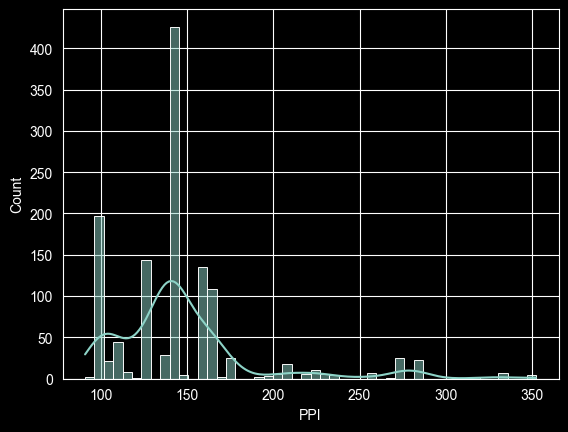

In [20]:
sns.histplot(clean_df["PPI"],kde=True)

<Axes: xlabel='PPI'>

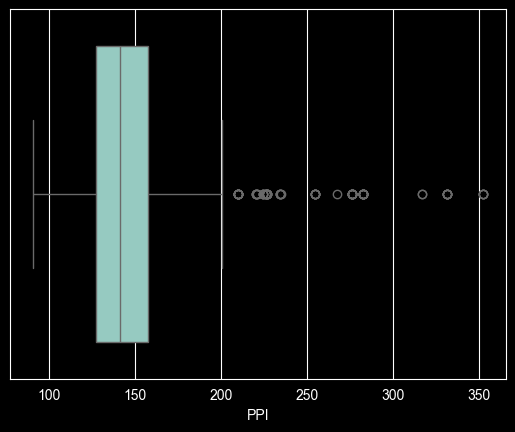

In [21]:
sns.boxplot(x=clean_df["PPI"])

<Axes: xlabel='IPS', ylabel='count'>

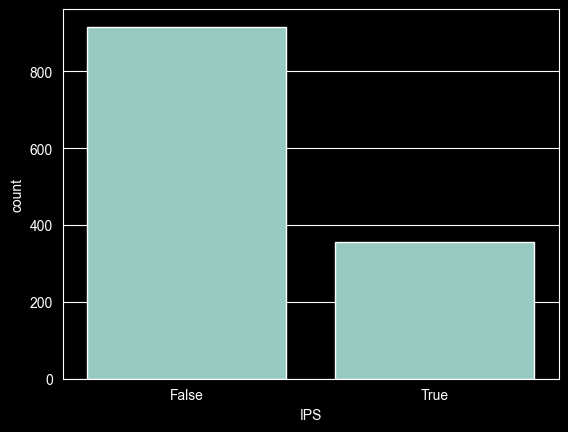

In [22]:
sns.countplot(data=clean_df,x="IPS")

<Axes: xlabel='Touchscreen', ylabel='count'>

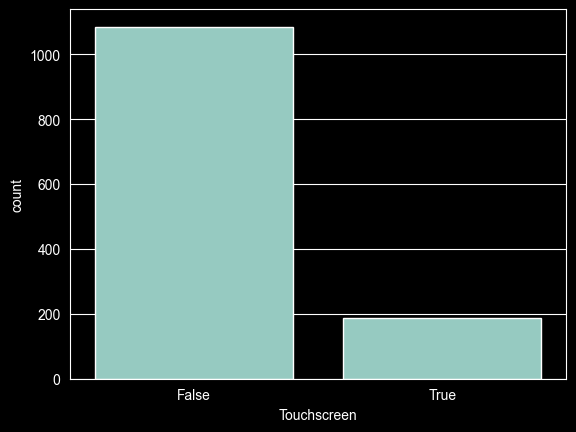

In [23]:
sns.countplot(data=clean_df,x="Touchscreen")

<Axes: xlabel='PPI', ylabel='Price_euros'>

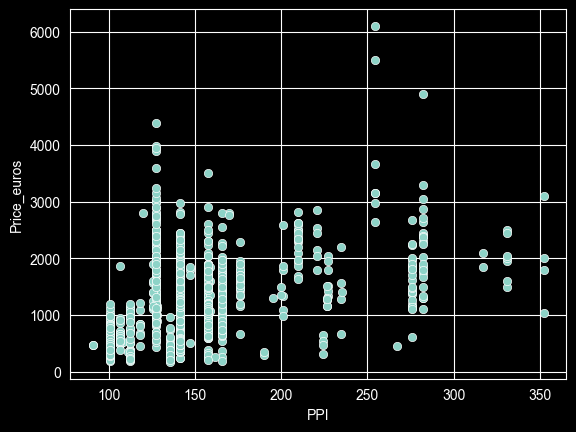

In [24]:
sns.scatterplot(data=clean_df,x="PPI",y="Price_euros")

<Axes: >

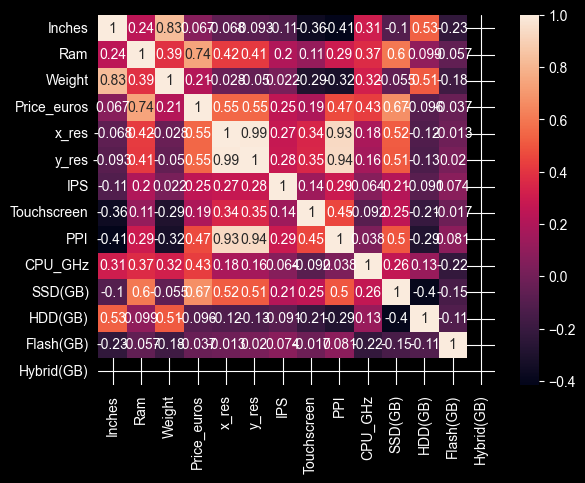

In [25]:
corr = clean_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

<Axes: xlabel='CPU_brand', ylabel='Count'>

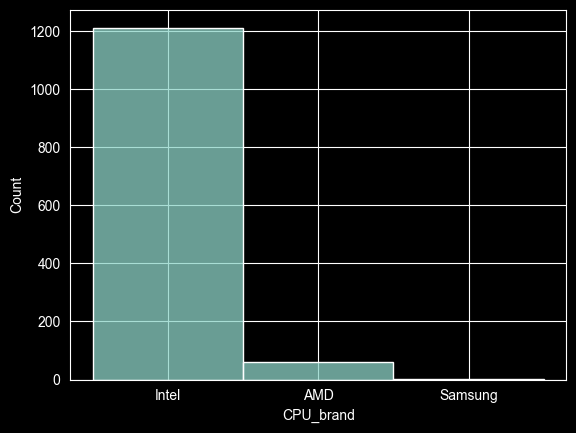

In [26]:
sns.histplot(data=clean_df,x="CPU_brand")

<Axes: xlabel='CPU_GHz', ylabel='Price_euros'>

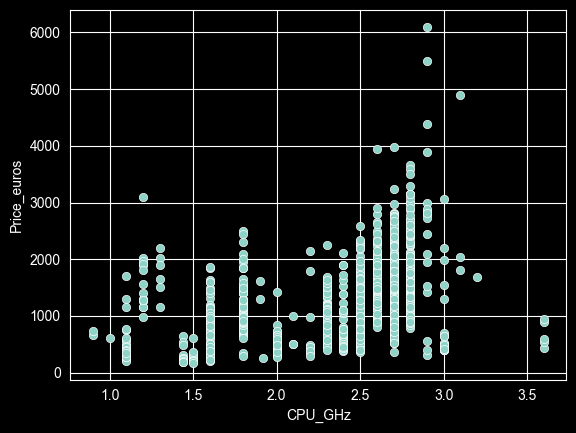

In [27]:
sns.scatterplot(data=clean_df,x="CPU_GHz",y="Price_euros")

<Axes: xlabel='SSD(GB)', ylabel='Price_euros'>

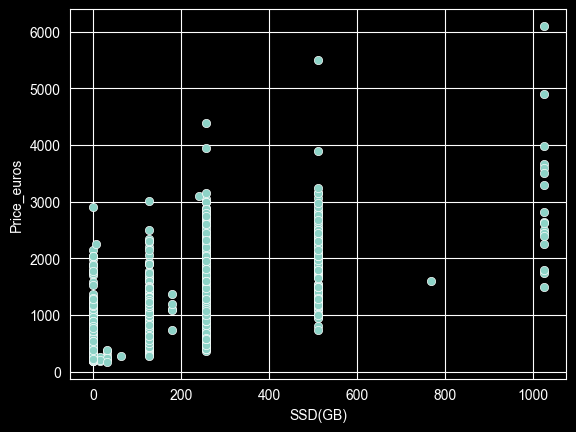

In [28]:
sns.scatterplot(data=clean_df,x="SSD(GB)",y="Price_euros")

<Axes: xlabel='GPU_brand', ylabel='count'>

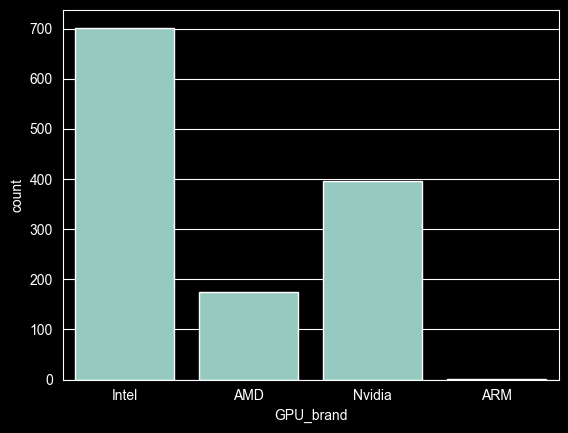

In [29]:
sns.countplot(data=clean_df,x="GPU_brand")

<Axes: xlabel='GPU_brand', ylabel='Price_euros'>

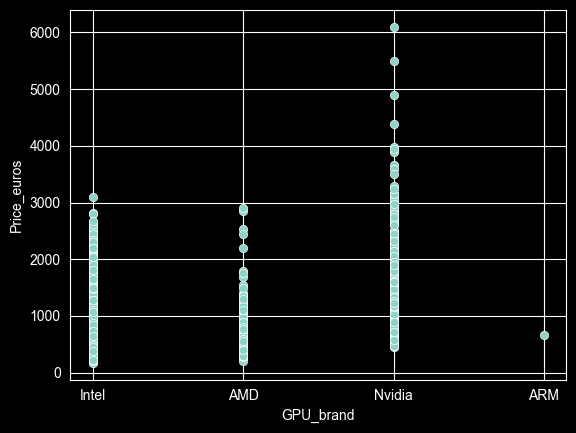

In [30]:
sns.scatterplot(data=clean_df,x="GPU_brand",y="Price_euros")

#### train/test split

In [31]:
from sklearn.model_selection import train_test_split
x=clean_df.drop("Price_euros",axis=1)
y=clean_df["Price_euros"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#### Data Preprocessing

In [32]:
clean_df.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price_euros,x_res,y_res,...,Touchscreen,PPI,CPU_brand,CPU_model,CPU_GHz,SSD(GB),HDD(GB),Flash(GB),Hybrid(GB),GPU_brand
0,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600,...,False,226.983005,Intel,Core i5,2.3,128.0,0.0,0.0,0,Intel
1,Apple,Ultrabook,13.3,8.0,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900,...,False,127.677940,Intel,Core i5,1.8,0.0,0.0,128.0,0,Intel
2,HP,Notebook,15.6,8.0,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080,...,False,141.211998,Intel,Core i5,2.5,256.0,0.0,0.0,0,Intel
3,Apple,Ultrabook,15.4,16.0,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800,...,False,220.534624,Intel,Core i7,2.7,512.0,0.0,0.0,0,AMD
4,Apple,Ultrabook,13.3,8.0,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600,...,False,226.983005,Intel,Core i5,3.1,256.0,0.0,0.0,0,Intel


In [33]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num",prep.StandardScaler(),['Inches','Ram','Weight','x_res','y_res','PPI','CPU_GHz',
                                      'SSD(GB)','HDD(GB)','Flash(GB)','Hybrid(GB)']),
        ('cat',prep.OneHotEncoder(handle_unknown="ignore"),['Company','TypeName','OpSys','CPU_brand','GPU_brand','CPU_model']),
    ]
)
trainx_prep=preprocessor.fit_transform(x_train)
testx_prep=preprocessor.transform(x_test)

### train model

#### Multiple Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(trainx_prep,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error
y_hat=regressor.predict(testx_prep)

print("MAE: %.2f"%mean_absolute_error(y_test,y_hat))
print("RMSE: %.2f"%root_mean_squared_error(y_test,y_hat))
print("MSE: %.2f"%mean_squared_error(y_test,y_hat))
print("R2: %.2f"%r2_score(y_test,y_hat))

MAE: 246.38
RMSE: 356.00
MSE: 126739.53
R2: 0.76
